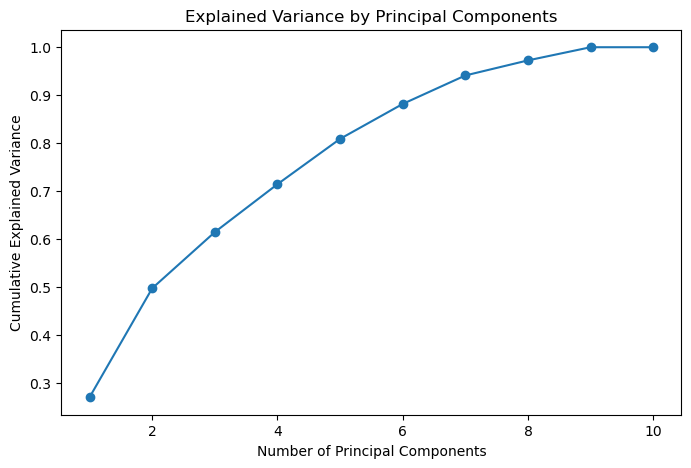

65% variance explained by 4 components.
70% variance explained by 4 components.
75% variance explained by 5 components.
80% variance explained by 5 components.
85% variance explained by 6 components.
90% variance explained by 7 components.
95% variance explained by 8 components.


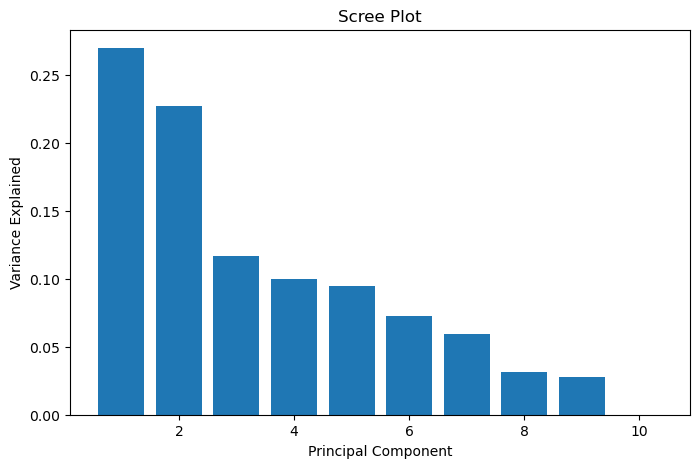

In [15]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Load data
df = pd.read_csv("Spotify_Dataset_V3.csv")

# Select only numeric features
numeric_df = df.select_dtypes(include=[np.number]).dropna()

# Scale the data (important for PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(numeric_df)

# Apply PCA
pca = PCA()
pca.fit(X_scaled)

# Calculate explained variance ratio
explained_variance = np.cumsum(pca.explained_variance_ratio_)

# Plot explained variance vs number of components
plt.figure(figsize=(8,5))
plt.plot(range(1, len(explained_variance)+1), explained_variance, marker='o')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by Principal Components')
plt.show()

# Find number of components for 65%, 70%, 75%, 80%, 85%, 90%, 95%
thresholds = [0.65, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95]
for t in thresholds:
    n_components = np.argmax(explained_variance >= t) + 1
    print(f"{t*100:.0f}% variance explained by {n_components} components.")

# Visualize the first two principal components
pca_2 = PCA(n_components=2)
X_pca = pca_2.fit_transform(X_scaled)

# Scree plot (individual component contribution)
plt.figure(figsize=(8,5))
plt.bar(range(1, len(pca.explained_variance_ratio_)+1), pca.explained_variance_ratio_)
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.title('Scree Plot')
plt.show()


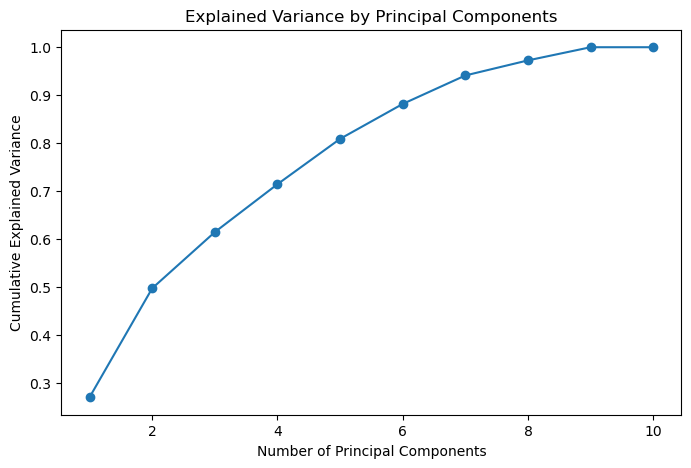

65% variance explained by 4 components.
70% variance explained by 4 components.
75% variance explained by 5 components.
80% variance explained by 5 components.
85% variance explained by 6 components.
90% variance explained by 7 components.
95% variance explained by 8 components.


In [21]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Load data
df = pd.read_csv("Spotify_Dataset_V3.csv")

# Select numeric features
numeric_df = df.select_dtypes(include=[np.number]).dropna()

# Data scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(numeric_df)

# PCA Application
pca = PCA()
pca.fit(X_scaled)

# Variance ratio Calculationn
explained_variance = np.cumsum(pca.explained_variance_ratio_)

# Plot explained variance vs number of components
plt.figure(figsize=(8,5))
plt.plot(range(1, len(explained_variance)+1), explained_variance, marker='o')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by Principal Components')
plt.show()

# Find number of components for 65%, 70%, 75%, 80%, 85%, 90%, 95%
thresholds = [0.65, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95]
for t in thresholds:
    n_components = np.argmax(explained_variance >= t) + 1
    print(f"{t*100:.0f}% variance explained by {n_components} components.")




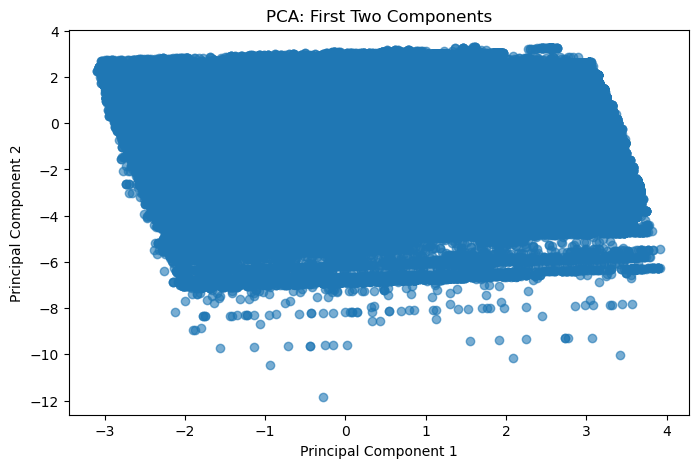

In [11]:
# Visualisation of the first two principal components
pca_2 = PCA(n_components=2)
X_pca = pca_2.fit_transform(X_scaled)

plt.figure(figsize=(8,5))
plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.6)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA: First Two Components')
plt.show()

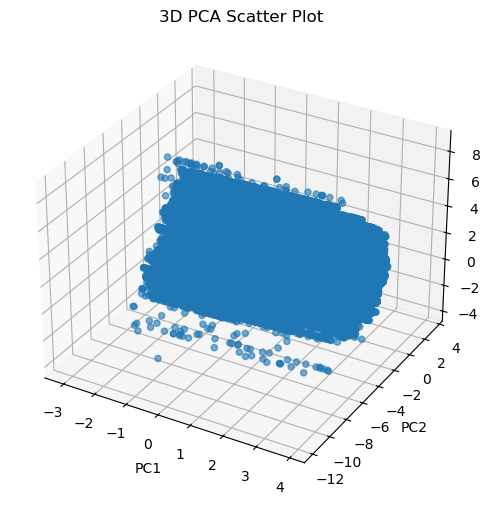

In [18]:
from mpl_toolkits.mplot3d import Axes3D

pca_3 = PCA(n_components=3)
X_pca3 = pca_3.fit_transform(X_scaled)

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_pca3[:,0], X_pca3[:,1], X_pca3[:,2], alpha=0.6)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('3D PCA Scatter Plot')
plt.show()


NameError: name 'X' is not defined

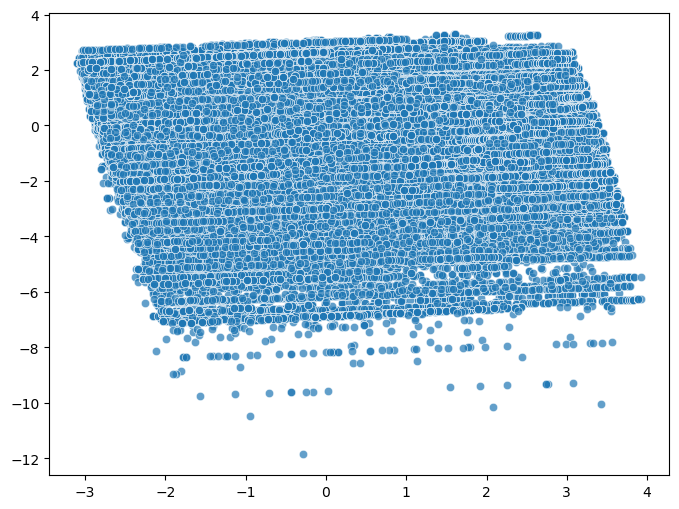

In [23]:
from sklearn.decomposition import PCA
import seaborn as sns

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], alpha=0.7)

# Plot arrows for feature loadings
for i, feature in enumerate(X.columns):
    plt.arrow(0, 0, 
              pca.components_[0, i]*3,  # scale for visibility
              pca.components_[1, i]*3,
              color='r', alpha=0.5)
    plt.text(pca.components_[0, i]*3.2,
             pca.components_[1, i]*3.2,
             feature, color='black', ha='center', va='center')

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Biplot')
plt.grid()
plt.show()


In [ ]:
pca_full = PCA(n_components=5)
X_pca_full = pca_full.fit_transform(X_scaled)
pca_df = pd.DataFrame(X_pca_full, columns=[f'PC{i+1}' for i in range(5)])

sns.pairplot(pca_df)
plt.show()
